# Phase 1 — Market-Derived Adjustments from Closed MLS Sales
### XGBoost against Random Forest, with the artifacts a production service needs

**Purpose:** estimate what the market actually pays for an additional bathroom, bedroom,
garage bay, and square foot of living area — using gradient-boosted trees on closed sales,
and leave behind a versioned model that a deployed API can serve.

**Workflow:**
1. Load and inspect data
2. Clean and engineer appraisal-relevant features
3. **Data adequacy diagnostics** (read these before trusting any adjustment)
4. Exploratory analysis and correlation
5. **Time-based** split — train on the earlier period, validate on the later one
6. Model 1: XGBoost -> **dollar adjustments** via counterfactual marginal effects
7. Bootstrap confidence intervals on each adjustment
8. Permutation importance -> **relative importance**
9. Model 2: Random Forest -> challenger and model comparison
10. Log-price model -> **percentage adjustments**
11. Subject property valuation
12. **Export the artifacts** — model, metadata, adjustment grid, drift reference

**To use a different MLS export:** edit only the `CONFIG` dictionary in Step 2.
Nothing else in the notebook needs to change.

---

### What changed from the regression notebook, and why

The linear notebook read its adjustments straight off the coefficients. XGBoost has no
coefficients, so steps 6, 7, 8 and 10 use a different estimator for the same quantity:

| Regression notebook | Here | Same question? |
|---|---|---|
| Coefficient | Average counterfactual marginal effect | Yes — both estimate the average price change from one more unit, other things equal |
| `t`-test p-value and OLS confidence interval | Percentile bootstrap interval | Yes — same decision rule: an interval spanning zero does not go in the grid |
| Standardized beta | Permutation importance | Yes — both rank drivers of price variation |
| `exp(coef) - 1` | `exp(mean log-delta) - 1` | Yes — percentage effect from a log-price model |

**The honest tradeoff.** A tree ensemble predicts better than OLS on this data but is a
*worse* instrument for reading a clean adjustment off, because boosting spreads credit
across correlated features and shrinks each one toward zero. Two things in this notebook
address that directly: monotone constraints (Step 6), which stop the grid from producing
an incoherent result like a third garage bay reducing value, and an OLS cross-check column
in the grid itself. **Where the two disagree sharply, trust neither and look at the
diagnostics.** That comparison is the most defensible thing in this notebook.

---

### The one rule that matters for Phase 2

Feature engineering lives in `app/features.py`, and this notebook **imports** it rather
than defining it inline. The FastAPI service imports the same file. There is no
copy-paste step and therefore no opportunity for the notebook and the API to drift apart.
If they ever disagree by one column, XGBoost will not raise an error — it will silently
return wrong dollar values. That is training/serving skew, and it is the most common
production ML bug there is.

# (install cell skipped during validation)

In [1]:
%pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn statsmodels openpyxl pyarrow boto3

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Imports

In [2]:
import json, os, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

# --- THE SHARED MODULE. Same file the API imports. Do not reimplement below. ---
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from app.features import (build_training_frame, build_design_matrix, build_serving_row,
                          NUMERIC_FEATURES, UNIT_LABELS, DEFAULT_STEPS, STEP_LABELS)
from app.adjustments import (adjustment_grid, percent_grid, location_effects,
                             contribution_breakdown, compare_scenarios, marginal_effect_rows)

if not sys.warnoptions:
    warnings.simplefilter("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)

print("Libraries imported successfully.")
print(f"xgboost {xgb.__version__} | repo root: {REPO_ROOT}")

Libraries imported successfully.
xgboost 3.4.1 | repo root: /home/claude/build/appraisal-api


## Step 2 — CONFIGURATION (the only cell you edit when swapping datasets)

Every dataset-specific choice lives here. When you export a different market, price band,
or time period from the MLS, change the values below and re-run the notebook top to bottom.

The `cols` dictionary maps **your MLS column names** (right side) to the **generic names
the model uses** (left side). If your next export calls living area something different,
change only the right side of that line.

Three settings are new relative to the regression notebook, and they exist because this
model gets deployed:

- **`model_version`** — the S3 prefix everything is written under. Bump it for every
  retrain. Never overwrite a version that a running service is loading.
- **`train_through`** — the time-based split point. Sales on or before this date train the
  model; sales after it validate it. `train_test_split(shuffle=True)` on time-series data
  leaks the future into training and inflates every metric you report.
- **`monotone`** — direction constraints. `+1` forces the model to never decrease price as
  the feature increases. Without this, boosting on a few hundred sales will happily produce
  a grid where the third garage bay is worth *less* than the second, which is indefensible
  in a report even when it is technically what the sample shows.

In [3]:
CONFIG = {
    # ------------------------------------------------------------------
    # FILE SETTINGS -- change these to point at a different export
    # ------------------------------------------------------------------
    "excel_path": "CARMEL_Excel_Fixed.xlsx",
    "sheet_name": "Sheet1",

    # ------------------------------------------------------------------
    # RECORD FILTERING -- restrict to arm's-length closed sales
    # ------------------------------------------------------------------
    "status_col":  "Status",
    "status_keep": "Sold",
    "target":      "Close Price",

    # ------------------------------------------------------------------
    # COLUMN MAPPING -- left = generic name used by the model
    #                   right = the column name in YOUR export
    # Set any entry to None if your export does not contain that field.
    # ------------------------------------------------------------------
    "cols": {
        "main_sqft":     "Main Level SqFt",
        "upper_sqft":    "Upper SqFt",
        "bsmt_fin_sqft": "Apprx Below Grade Fin SqFt",
        "bedrooms":      "Bedrooms",
        "baths_full":    "Baths Full",
        "baths_half":    "Baths Half",
        "garage_spaces": "Garage Spaces",
        "fireplaces":    "Fireplaces",
        "lot_sqft":      "Lot Size SqFt",
        "year_built":    "Year Built",
        "close_date":    "Close Date",
        "location":      "Area",
        "concessions":   "Concessions",
    },

    # ------------------------------------------------------------------
    # MODELING
    # ------------------------------------------------------------------
    "net_concessions":     True,   # subtract seller concessions -> cash-equivalent price
    "min_location_count":  15,     # locations with fewer sales get pooled into "Other"
    "min_level_count":     10,     # Diagnostic B: sales needed to call a level supported
    "random_state":        42,
    "n_bootstrap":         400,    # resamples for the adjustment confidence intervals

    # TIME-BASED SPLIT. Set to None to fall back to the most recent 20% as the
    # validation set, which is the same idea without hard-coding a date.
    "train_through":       None,   # e.g. "2024-12-31"
    "test_fraction":       0.20,

    # Monotone direction per feature: +1 up, -1 down, 0 unconstrained.
    # bedrooms is left at 0 deliberately -- see the note in Step 6.
    "monotone": {
        "gla_sqft": 1, "bsmt_fin_sqft": 1, "bedrooms": 0, "baths_full": 1,
        "baths_half": 1, "garage_spaces": 1, "fireplaces": 1, "lot_sqft": 1,
        "age_at_sale": -1, "months_since_start": 1,
    },

    # ------------------------------------------------------------------
    # ARTIFACT DESTINATION (Phase 1 output -> Phase 2 input)
    # ------------------------------------------------------------------
    "model_version":  "v1",
    "s3_bucket":      None,        # e.g. "yourname-appraisal-models"; None = local only
    "s3_prefix":      "models",    # final path: s3://bucket/models/v1/
    "local_artifacts": "artifacts",
    "aws_region":     "us-east-2",
}

print("CONFIG loaded.")
print(f"  Artifacts -> {CONFIG['local_artifacts']}/{CONFIG['model_version']}/")
print(f"  S3        -> " + (f"s3://{CONFIG['s3_bucket']}/{CONFIG['s3_prefix']}/{CONFIG['model_version']}/"
                            if CONFIG["s3_bucket"] else "not configured (local only)"))

CONFIG loaded.
  Artifacts -> artifacts/v1/
  S3        -> not configured (local only)


## Step 3 — Load the dataset

If the export is not found, the cell below generates a synthetic MLS-shaped sample so the
notebook runs end to end. **The synthetic path is for wiring up Phases 2 to 4 only.** Every
number it produces is invented and none of it belongs in a report. The banner will not let
you forget which mode you are in.

In [4]:
USING_SYNTHETIC = False

if os.path.exists(CONFIG["excel_path"]):
    df_raw = pd.read_excel(CONFIG["excel_path"], sheet_name=CONFIG["sheet_name"])
    print("Dataset loaded successfully!")
else:
    USING_SYNTHETIC = True
    rng = np.random.default_rng(CONFIG["random_state"])
    N = 900
    main  = rng.normal(1500, 380, N).clip(700, 3200)
    upper = np.where(rng.random(N) < 0.55, rng.normal(900, 320, N).clip(0, 2100), 0)
    bsmt  = np.where(rng.random(N) < 0.50, rng.normal(700, 320, N).clip(0, 1900), 0)
    beds, bf, bh = rng.integers(2, 6, N), rng.integers(1, 5, N), rng.integers(0, 3, N)
    gar, fp = rng.integers(1, 4, N), rng.integers(0, 3, N)
    lot = rng.normal(11000, 4200, N).clip(3000, 45000)
    yb  = rng.integers(1958, 2023, N)
    dates = pd.to_datetime("2023-01-01") + pd.to_timedelta(rng.integers(0, 950, N), unit="D")
    locs = rng.choice(["Carmel", "Westfield", "Zionsville", "Fishers"], N, p=[.40, .25, .20, .15])
    price = (95_000 + 118*(main+upper) + 42*bsmt + 9_500*bf + 4_200*bh + 8_800*gar
             + 5_100*fp + 3.1*lot - 950*(dates.year - yb)
             + 1_200*((dates.year - 2023)*12 + dates.month - 1)
             + pd.Series(locs).map({"Carmel": 40_000, "Westfield": 0,
                                    "Zionsville": 55_000, "Fishers": 15_000}).values
             + rng.normal(0, 30_000, N))
    df_raw = pd.DataFrame({
        "Status": "Sold", "Close Price": price.round(-2),
        "Main Level SqFt": main.round(0), "Upper SqFt": upper.round(0),
        "Apprx Below Grade Fin SqFt": bsmt.round(0), "Bedrooms": beds,
        "Baths Full": bf, "Baths Half": bh, "Garage Spaces": gar.astype(str),
        "Fireplaces": fp, "Lot Size SqFt": lot.round(0), "Year Built": yb,
        "Close Date": dates, "Area": locs, "Concessions": 0,
    })
    print("!" * 78)
    print("SYNTHETIC DATA IN USE -- '" + CONFIG["excel_path"] + "' was not found.")
    print("Every figure below is fabricated. Use this only to wire up the pipeline.")
    print("!" * 78)

print(f"\nDataset shape: {df_raw.shape}")
print(f"Number of rows (listings): {df_raw.shape[0]}")
print(f"Number of columns (fields): {df_raw.shape[1]}")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
SYNTHETIC DATA IN USE -- 'CARMEL_Excel_Fixed.xlsx' was not found.
Every figure below is fabricated. Use this only to wire up the pipeline.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Dataset shape: (900, 15)
Number of rows (listings): 900
Number of columns (fields): 15


In [5]:
print("First 5 rows of the dataset:")
print("=" * 80)
df_raw.head(5)

First 5 rows of the dataset:


,Status,Close Price,Main Level SqFt,Upper SqFt,Apprx Below Grade Fin SqFt,Bedrooms,Baths Full,Baths Half,Garage Spaces,Fireplaces,Lot Size SqFt,Year Built,Close Date,Area,Concessions
0,Sold,"445,200.00","1,616.00",391.00,"1,237.00",4,3,1,2,1,"9,007.00",1960,2024-01-31,Carmel,0
1,Sold,"454,500.00","1,105.00",0.00,930.00,3,4,1,2,2,"7,484.00",1986,2025-01-31,Carmel,0
2,Sold,"417,900.00","1,785.00",0.00,0.00,2,2,1,3,0,"6,406.00",1993,2023-06-29,Fishers,0
3,Sold,"497,100.00","1,857.00",369.00,0.00,5,4,0,1,0,"12,777.00",1990,2024-09-27,Carmel,0
4,Sold,"389,400.00",759.00,0.00,972.00,5,3,1,1,0,"16,775.00",2008,2025-07-22,Carmel,0


In [6]:
# Verify every column named in CONFIG actually exists. This catches typos and
# MLS column renames before they cause confusing errors deeper in the pipeline.
print("CONFIG column mapping check:")
print("=" * 80)

missing_cols = []
for generic_name, mls_name in CONFIG["cols"].items():
    if mls_name is None:
        print(f"  [skip]    {generic_name:15s} -> not provided")
    elif mls_name in df_raw.columns:
        print(f"  [ok]      {generic_name:15s} -> '{mls_name}'")
    else:
        print(f"  [MISSING] {generic_name:15s} -> '{mls_name}' NOT FOUND")
        missing_cols.append((generic_name, mls_name))

if missing_cols:
    print(f"\n{len(missing_cols)} mapped column(s) were not found.")
    print("Fix the right-hand side of CONFIG['cols'] before continuing.")
else:
    print("\nAll mapped columns located successfully.")

CONFIG column mapping check:
  [ok]      main_sqft       -> 'Main Level SqFt'
  [ok]      upper_sqft      -> 'Upper SqFt'
  [ok]      bsmt_fin_sqft   -> 'Apprx Below Grade Fin SqFt'
  [ok]      bedrooms        -> 'Bedrooms'
  [ok]      baths_full      -> 'Baths Full'
  [ok]      baths_half      -> 'Baths Half'
  [ok]      garage_spaces   -> 'Garage Spaces'
  [ok]      fireplaces      -> 'Fireplaces'
  [ok]      lot_sqft        -> 'Lot Size SqFt'
  [ok]      year_built      -> 'Year Built'
  [ok]      close_date      -> 'Close Date'
  [ok]      location        -> 'Area'
  [ok]      concessions     -> 'Concessions'

All mapped columns located successfully.


## Step 4 — Data quality: missing values and duplicates

In [7]:
print("Missing Values Analysis (mapped fields only):")
print("=" * 80)

mapped = [v for v in CONFIG["cols"].values() if v is not None and v in df_raw.columns]
mapped += [CONFIG["target"], CONFIG["status_col"]]

missing_df = pd.DataFrame({
    "Missing Count": df_raw[mapped].isnull().sum(),
    "Percentage": (df_raw[mapped].isnull().sum() / len(df_raw) * 100).round(1),
}).sort_values("Missing Count", ascending=False)
print(missing_df.to_string())
print("\nFields missing more than 50% of values are poor adjustment candidates.")

duplicates = df_raw.duplicated().sum()
print(f"\nFully duplicated rows: {duplicates}")
if duplicates:
    df_raw = df_raw.drop_duplicates()
    print(f"Removed. New shape: {df_raw.shape}")

Missing Values Analysis (mapped fields only):
                            Missing Count  Percentage
Main Level SqFt                         0        0.00
Upper SqFt                              0        0.00
Apprx Below Grade Fin SqFt              0        0.00
Bedrooms                                0        0.00
Baths Full                              0        0.00
Baths Half                              0        0.00
Garage Spaces                           0        0.00
Fireplaces                              0        0.00
Lot Size SqFt                           0        0.00
Year Built                              0        0.00
Close Date                              0        0.00
Area                                    0        0.00
Concessions                             0        0.00
Close Price                             0        0.00
Status                                  0        0.00

Fields missing more than 50% of values are poor adjustment candidates.

Fully duplicated 

## Step 5 — Filter to closed sales

Active and pending listings carry an asking price, not a transaction price. Only closed
sales represent what the market actually paid, so those are the only records that can
support a market-derived adjustment.

In [8]:
print("Filtering to closed sales:")
print("=" * 80)
print("Status distribution in the full export:")
print(df_raw[CONFIG["status_col"]].value_counts().to_string())

df_sold = df_raw[df_raw[CONFIG["status_col"]] == CONFIG["status_keep"]].copy()
df_sold = df_sold[df_sold[CONFIG["target"]].notna()]

print(f"\nClosed sales retained: {len(df_sold)} of {len(df_raw)} records")
print(f"Records dropped:       {len(df_raw) - len(df_sold)}")

Filtering to closed sales:
Status distribution in the full export:
Status
Sold    900

Closed sales retained: 900 of 900 records
Records dropped:       0


## Step 6 — Feature engineering (imported, not written here)

This is where MLS fields become appraisal variables. The logic lives in `app/features.py`
and the same function runs inside the API. Three choices matter, and they are unchanged
from the regression notebook:

**Above-grade GLA is built from Main + Upper square footage.** `Apprx Total Finished SqFt`
already includes finished basement area, so using it directly would blend above-grade and
below-grade space into a single rate. Appraisers price those separately because below-grade
finished area typically contributes a fraction of the above-grade rate. Keeping them as
two variables lets the model estimate both rates.

**Full and half baths are kept separate.** Collapsing them into `Baths Total` forces the
model to assume a half bath contributes the same as a full bath.

**Age at sale, not year built.** Age is directly interpretable as a depreciation rate in
dollars per year, and it is measured relative to each sale's own closing date.

**Months since first sale** captures market conditions — the time adjustment appraisers
apply when comparables closed months before the effective date.

In [9]:
data, meta_bits = build_training_frame(df_sold, CONFIG)

print("Engineered modeling variables:")
print("=" * 80)
print(f"Sales after engineering: {len(data)}")
print(f"Market anchor date:      {meta_bits['anchor_date']}")
if CONFIG["net_concessions"]:
    print(f"Sales with concessions netted from price: {meta_bits['concessions_netted']}")

print("\nStatistical Summary of Modeling Variables:")
data[NUMERIC_FEATURES + ["sale_price", "ppsf"]].describe().T.round(2)

Engineered modeling variables:
Sales after engineering: 900
Market anchor date:      2023-01-02
Sales with concessions netted from price: 0

Statistical Summary of Modeling Variables:


,count,mean,std,min,25%,50%,75%,max
gla_sqft,900.00,"1,984.89",635.14,700.00,"1,523.75","1,961.00","2,456.75","3,763.00"
bsmt_fin_sqft,900.00,348.47,416.18,0.00,0.00,0.00,701.25,"1,610.00"
bedrooms,900.00,3.48,1.09,2.00,3.00,3.00,4.00,5.00
baths_full,900.00,2.48,1.11,1.00,1.00,2.00,3.00,4.00
baths_half,900.00,1.03,0.81,0.00,0.00,1.00,2.00,2.00
garage_spaces,900.00,1.98,0.81,1.00,1.00,2.00,3.00,3.00
fireplaces,900.00,0.94,0.81,0.00,0.00,1.00,2.00,2.00
lot_sqft,900.00,"10,993.74","4,082.68","3,000.00","8,219.75","10,684.00","13,659.25","24,834.00"
age_at_sale,900.00,33.25,18.78,1.00,17.00,33.00,50.00,67.00
months_since_start,900.00,15.36,9.01,0.00,8.00,16.00,23.00,31.00


---
# DIAGNOSTICS — read these before trusting any adjustment

The two cells below are not decorative. No model — linear or boosted — can measure a price
effect if the sample does not contain variation in price and in the feature. These tests
check both conditions and tell you which of your questions this particular export can
answer.

## Diagnostic A — Price range restriction

This is the single most consequential test in the notebook.

If an MLS search was filtered to a narrow price band, the sample is **selected on the
dependent variable**. Inside a fixed band, a larger house must be worse in some other way
to still land in that band — older, smaller lot, inferior location. The model sees those
offsetting tradeoffs and reports a square-foot rate far below the true market rate. This is
range restriction, and no modeling technique repairs it. Boosting does not repair it
either. The only fix is a wider export.

In [10]:
print("DIAGNOSTIC A: PRICE RANGE RESTRICTION")
print("=" * 80)

price = data["sale_price"]
price_range_ratio = float(price.max() / price.min())
price_cv = float(price.std() / price.mean())
raw_ppsf = float(data["ppsf"].median())
gla_corr = float(price.corr(data["gla_sqft"]))

print(f"Sale price minimum:            ${price.min():,.0f}")
print(f"Sale price maximum:            ${price.max():,.0f}")
print(f"Max / min ratio:                {price_range_ratio:.2f}x")
print(f"Coefficient of variation:       {price_cv:.3f}")
print(f"Raw median price per sq ft:    ${raw_ppsf:,.2f}")
print(f"Correlation(price, GLA):        {gla_corr:.3f}")

print("\n" + "-" * 80)
print("INTERPRETATION")
print("-" * 80)

flags = []
if price_range_ratio < 2.0:
    flags.append(f"Price span is only {price_range_ratio:.2f}x. An unfiltered market pull "
                 "normally spans 4x or more.")
if price_cv < 0.20:
    flags.append(f"Coefficient of variation is {price_cv:.3f}. Below roughly 0.20 indicates "
                 "the price field was filtered.")
if gla_corr < 0.60:
    flags.append(f"Price-to-GLA correlation is only {gla_corr:.3f}. In an unrestricted sample "
                 "this is typically 0.70 to 0.90.")

if flags:
    print("RANGE RESTRICTION DETECTED:\n")
    for f in flags:
        print(f"  - {f}")
    print("\nCONSEQUENCE: every adjustment below is biased toward zero. The dollar")
    print("figures will understate what the market actually pays. Widen the export.")
else:
    print("No range restriction detected. The sample spans enough price variation")
    print("to estimate marginal effects.")

DIAGNOSTICS = {
    "price_range_ratio": price_range_ratio, "price_cv": price_cv,
    "raw_median_ppsf": raw_ppsf, "gla_corr": gla_corr, "flags": flags,
}

DIAGNOSTIC A: PRICE RANGE RESTRICTION
Sale price minimum:            $200,100
Sale price maximum:            $708,300
Max / min ratio:                3.54x
Coefficient of variation:       0.207
Raw median price per sq ft:    $224.49
Correlation(price, GLA):        0.849

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
No range restriction detected. The sample spans enough price variation
to estimate marginal effects.


## Diagnostic B — Feature support

An adjustment for "garage spaces" is only meaningful if the sample contains a reasonable
number of homes at more than one garage size. If 90% of sales are 2-car, the model has
almost nothing to compare against and its garage adjustment is noise.

This matters *more* for a tree model than for a regression. A linear model will happily
extrapolate a straight line through a level it has barely seen; a tree simply has no split
there and returns a flat effect. Both answers are unreliable, but the tree's failure is
quieter, which is why the `Share_Responsive` column in the grid exists.

In [11]:
print("DIAGNOSTIC B: FEATURE SUPPORT")
print("=" * 80)
print("Can this sample answer your question about each feature?\n")

discrete_features = ["bedrooms", "baths_full", "baths_half", "garage_spaces", "fireplaces"]
support_report = []

for feat in discrete_features:
    counts = data[feat].value_counts().sort_index()
    supported_levels = int((counts >= CONFIG["min_level_count"]).sum())
    dominant_share = float(counts.max() / counts.sum())

    print(f"{feat}:")
    for level, n in counts.items():
        bar = "#" * int(50 * n / counts.max())
        print(f"   {level:>5.1f} : {n:4d}  {bar}")
    print(f"   -> {supported_levels} level(s) with >= {CONFIG['min_level_count']} sales; "
          f"largest level holds {dominant_share:.0%} of the sample")

    if supported_levels < 2:
        verdict = "CANNOT ESTIMATE - needs at least two well-populated levels"
    elif dominant_share > 0.80:
        verdict = "WEAK - one level dominates; treat the adjustment as indicative only"
    else:
        verdict = "OK - sufficient variation to estimate an adjustment"
    print(f"   VERDICT: {verdict}\n")
    support_report.append({"Feature": feat, "Levels >= threshold": supported_levels,
                           "Dominant share": round(dominant_share, 3), "Verdict": verdict})

pd.DataFrame(support_report)

DIAGNOSTIC B: FEATURE SUPPORT
Can this sample answer your question about each feature?

bedrooms:
     2.0 :  216  ############################################
     3.0 :  244  ##################################################
     4.0 :  230  ###############################################
     5.0 :  210  ###########################################
   -> 4 level(s) with >= 10 sales; largest level holds 27% of the sample
   VERDICT: OK - sufficient variation to estimate an adjustment

baths_full:
     1.0 :  226  ################################################
     2.0 :  234  ##################################################
     3.0 :  221  ###############################################
     4.0 :  219  ##############################################
   -> 4 level(s) with >= 10 sales; largest level holds 26% of the sample
   VERDICT: OK - sufficient variation to estimate an adjustment

baths_half:
     0.0 :  286  ##############################################
     1.0 :  305  ##

,Feature,Levels >= threshold,Dominant share,Verdict
0,bedrooms,4,0.27,OK - sufficient variation to estimate an adjus...
1,baths_full,4,0.26,OK - sufficient variation to estimate an adjus...
2,baths_half,3,0.34,OK - sufficient variation to estimate an adjus...
3,garage_spaces,3,0.35,OK - sufficient variation to estimate an adjus...
4,fireplaces,3,0.36,OK - sufficient variation to estimate an adjus...


---
## Step 7 — Exploratory analysis

Naive group comparisons come first. These show the **unadjusted** price difference between,
say, 3-bedroom and 4-bedroom homes. They are not adjustments — a 4-bedroom home is also
usually larger, newer, and better located, so the raw gap bundles all of those together.
The model later isolates the bedroom effect by holding the rest constant. Comparing the
two numbers is instructive.

RAW PRICE PER SQUARE FOOT (above-grade GLA)
Mean:               $235.92
Median:             $224.49
Std deviation:      $53.70
25th percentile:    $199.43
75th percentile:    $257.51

NOTE: this is an AVERAGE rate (price / total size), which includes land,
site improvements, and every amenity spread across the square footage.
It is NOT the same as the MARGINAL rate the model estimates -- the amount
the market pays for one ADDITIONAL square foot. The marginal rate is the
correct basis for a size adjustment and is normally lower.


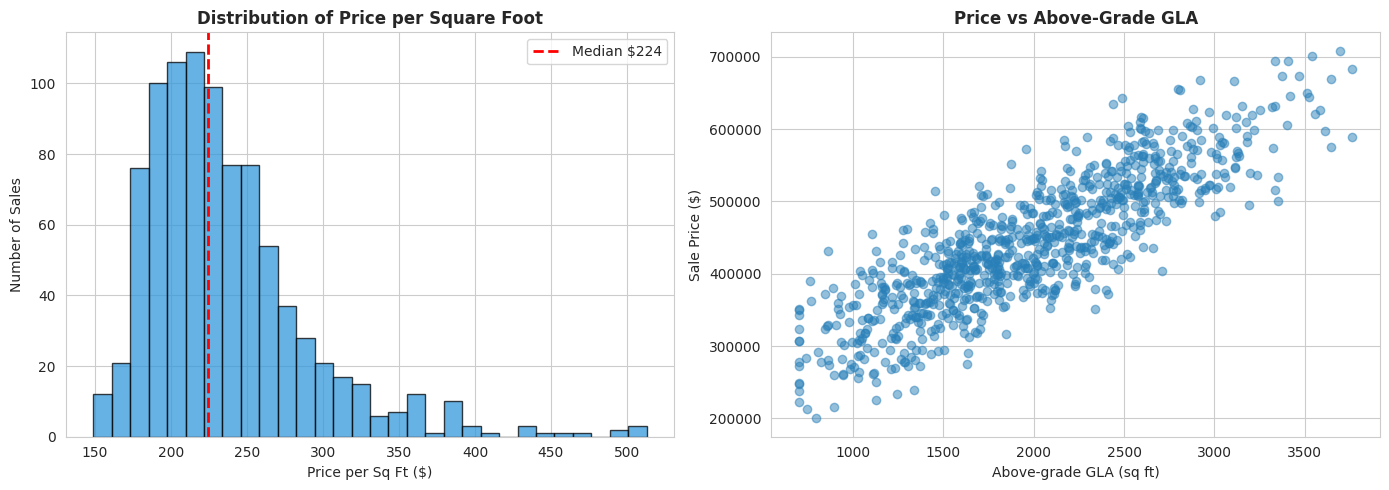

In [12]:
print("RAW PRICE PER SQUARE FOOT (above-grade GLA)")
print("=" * 80)
print(f"Mean:               ${data['ppsf'].mean():,.2f}")
print(f"Median:             ${data['ppsf'].median():,.2f}")
print(f"Std deviation:      ${data['ppsf'].std():,.2f}")
print(f"25th percentile:    ${data['ppsf'].quantile(0.25):,.2f}")
print(f"75th percentile:    ${data['ppsf'].quantile(0.75):,.2f}")

print("\nNOTE: this is an AVERAGE rate (price / total size), which includes land,")
print("site improvements, and every amenity spread across the square footage.")
print("It is NOT the same as the MARGINAL rate the model estimates -- the amount")
print("the market pays for one ADDITIONAL square foot. The marginal rate is the")
print("correct basis for a size adjustment and is normally lower.")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(data["ppsf"], bins=30, color="#3498db", edgecolor="black", alpha=0.75)
ax[0].axvline(data["ppsf"].median(), color="red", linestyle="--", lw=2,
              label=f"Median ${data['ppsf'].median():,.0f}")
ax[0].set_xlabel("Price per Sq Ft ($)"); ax[0].set_ylabel("Number of Sales")
ax[0].set_title("Distribution of Price per Square Foot", fontweight="bold"); ax[0].legend()

ax[1].scatter(data["gla_sqft"], data["sale_price"], alpha=0.5, color="#2980b9")
ax[1].set_xlabel("Above-grade GLA (sq ft)"); ax[1].set_ylabel("Sale Price ($)")
ax[1].set_title("Price vs Above-Grade GLA", fontweight="bold")
plt.tight_layout(); plt.show()

In [13]:
print("UNADJUSTED PRICE BY FEATURE LEVEL")
print("=" * 80)
print("These bundle every other difference between the groups.\n")

for feat in ["bedrooms", "baths_full", "baths_half", "garage_spaces"]:
    summary = data.groupby(feat).agg(
        Count=("sale_price", "count"), Mean_Price=("sale_price", "mean"),
        Median_Price=("sale_price", "median"), Mean_GLA=("gla_sqft", "mean"),
    ).round(0)
    summary["Raw_Step_Change"] = summary["Mean_Price"].diff().round(0)
    print(f"\n--- {feat} ---")
    print(summary.to_string())

print("\n" + "-" * 80)
print("Watch the Mean_GLA column: if it rises alongside the feature level, the")
print("raw step change is mostly measuring size, not the feature itself.")

UNADJUSTED PRICE BY FEATURE LEVEL
These bundle every other difference between the groups.


--- bedrooms ---
          Count  Mean_Price  Median_Price  Mean_GLA  Raw_Step_Change
bedrooms                                                            
2           216  442,229.00    436,800.00  1,974.00              NaN
3           244  445,900.00    441,700.00  1,993.00         3,671.00
4           230  442,578.00    426,950.00  1,987.00        -3,322.00
5           210  440,090.00    436,200.00  1,983.00        -2,488.00

--- baths_full ---
            Count  Mean_Price  Median_Price  Mean_GLA  Raw_Step_Change
baths_full                                                            
1             226  421,933.00    416,500.00  1,927.00              NaN
2             234  444,563.00    437,600.00  2,002.00        22,630.00
3             221  449,553.00    449,500.00  2,031.00         4,990.00
4             219  455,693.00    449,500.00  1,980.00         6,140.00

--- baths_half ---
           

CORRELATION MATRIX


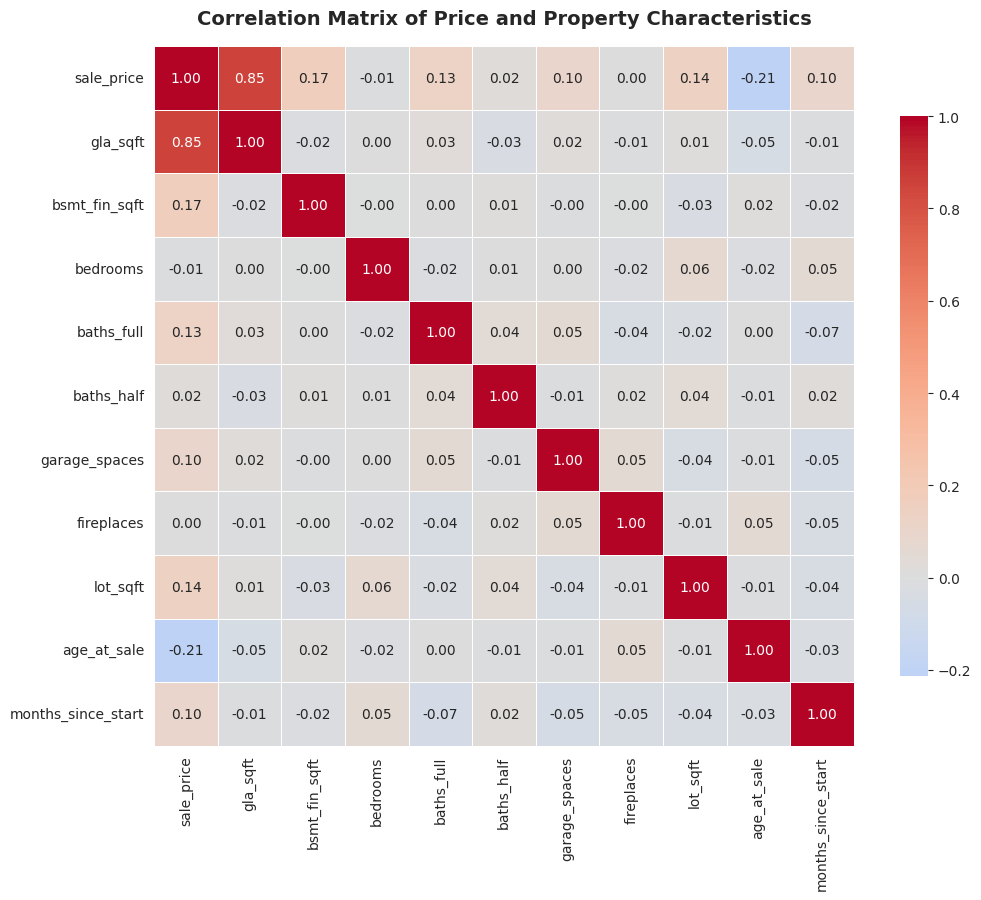


Correlation with sale price, strongest first:
gla_sqft              0.85
bsmt_fin_sqft         0.17
lot_sqft              0.14
baths_full            0.13
garage_spaces         0.10
months_since_start    0.10
baths_half            0.02
fireplaces            0.00
bedrooms             -0.01
age_at_sale          -0.21

Feature pairs correlated above 0.70 (these share credit in any model):
  None.


In [14]:
print("CORRELATION MATRIX")
print("=" * 80)
corr_cols = ["sale_price"] + NUMERIC_FEATURES
correlation_matrix = data[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Price and Property Characteristics",
          fontsize=14, fontweight="bold", pad=16)
plt.tight_layout(); plt.show()

print("\nCorrelation with sale price, strongest first:")
print(correlation_matrix["sale_price"].drop("sale_price").sort_values(ascending=False).round(3).to_string())

print("\nFeature pairs correlated above 0.70 (these share credit in any model):")
found = False
for i in range(1, len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        r = correlation_matrix.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {corr_cols[i]} <-> {corr_cols[j]}: {r:.3f}")
            found = True
if not found:
    print("  None.")
else:
    print("\nBoosting splits the credit between correlated features somewhat arbitrarily.")
    print("Their individual adjustments are less stable than the pair's combined effect.")

---
## Step 8 — Feature matrix and time-based split

Location is one-hot encoded, with one level held out as the baseline. Every `loc_`
adjustment then reads as a dollar difference relative to that baseline, which is exactly
the form a location adjustment takes.

**The split is by date, not at random.** Train on the earlier sales, validate on the later
ones. A random split lets the model see sales from next quarter while learning to price
this one, which inflates every metric you report and hides exactly the failure mode you
care about: a model that has stopped tracking a moving market. It is also what makes
Phase 4 possible — the held-out later period is the traffic you replay through the
deployed API to generate real drift.

In [15]:
X, y, baseline_loc, location_levels = build_design_matrix(data, CONFIG["min_location_count"])

print("Location grouping:")
print("=" * 80)
print(data["location"].value_counts().to_string())

print(f"\nFeature matrix (X): {X.shape[0]} sales x {X.shape[1]} features")
print(f"Target (y):         {CONFIG['target']}"
      f"{' net of concessions' if CONFIG['net_concessions'] else ''}")
print(f"Baseline location:  {baseline_loc} (all loc_ adjustments are relative to this)")
print(f"\nFeatures IN ORDER: {list(X.columns)}")

Location grouping:
location
Carmel        357
Westfield     230
Zionsville    180
Fishers       133

Feature matrix (X): 900 sales x 13 features
Target (y):         Close Price net of concessions
Baseline location:  Carmel (all loc_ adjustments are relative to this)

Features IN ORDER: ['gla_sqft', 'bsmt_fin_sqft', 'bedrooms', 'baths_full', 'baths_half', 'garage_spaces', 'fireplaces', 'lot_sqft', 'age_at_sale', 'months_since_start', 'loc_Fishers', 'loc_Westfield', 'loc_Zionsville']


In [16]:
# TIME-BASED SPLIT -- never train_test_split(shuffle=True) on time-series
dates = data.loc[X.index, "close_date"]

if CONFIG["train_through"]:
    cutoff = pd.Timestamp(CONFIG["train_through"])
else:
    cutoff = dates.quantile(1 - CONFIG["test_fraction"])

train_mask = dates <= cutoff
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("TIME-BASED TRAIN/TEST SPLIT")
print("=" * 80)
print(f"Split date:      {pd.Timestamp(cutoff).date()}")
print(f"Training sales:  {len(X_train):4d} ({len(X_train)/len(X)*100:.1f}%)  "
      f"{dates[train_mask].min().date()} to {dates[train_mask].max().date()}")
print(f"Testing sales:   {len(X_test):4d} ({len(X_test)/len(X)*100:.1f}%)  "
      f"{dates[~train_mask].min().date()} to {dates[~train_mask].max().date()}")
print(f"\nMean price, training period: ${y_train.mean():,.0f}")
print(f"Mean price, testing period:  ${y_test.mean():,.0f}")
print(f"Difference:                  {(y_test.mean()/y_train.mean() - 1)*100:+.1f}%")
print("\nThat difference IS market movement. The model has to learn it from")
print("months_since_start rather than having seen the later sales directly.")

TIME-BASED TRAIN/TEST SPLIT
Split date:      2025-02-01
Training sales:   720 (80.0%)  2023-01-02 to 2025-02-01
Testing sales:    180 (20.0%)  2025-02-02 to 2025-08-07

Mean price, training period: $439,884
Mean price, testing period:  $454,533
Difference:                  +3.3%

That difference IS market movement. The model has to learn it from
months_since_start rather than having seen the later sales directly.


---
## Step 9 — Model 1: XGBoost (the champion)

**Why monotone constraints.** Left unconstrained, gradient boosting on a few hundred sales
will produce local reversals: a garage adjustment that goes up from one bay to two and back
down from two to three, because a handful of three-car sales happened to be cheap. That is
real noise in the sample, but it is indefensible in an appraisal report and it makes the
adjustment grid incoherent. `monotone_constraints` forbids those reversals during training.
It costs a little accuracy and buys a grid you can actually put in front of a reviewer.

**Why `bedrooms` is left unconstrained.** Its true effect, holding square footage constant,
is often negative — more bedrooms in the same space means smaller rooms. Forcing it upward
would be imposing an answer rather than measuring one.

In [17]:
mono_tuple = tuple(CONFIG["monotone"].get(c, 0) for c in X.columns)

xgb_params = dict(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,             # shallow: this is a few hundred rows, not a million
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,      # a leaf must represent several real sales
    reg_lambda=1.0,
    random_state=CONFIG["random_state"],
    monotone_constraints=mono_tuple,
    n_jobs=-1,
)

print("MODEL 1: XGBOOST REGRESSOR")
print("=" * 80)
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)

r2_train  = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_test   = r2_score(y_test, y_test_pred)
mae_test  = mean_absolute_error(y_test, y_test_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("\nMonotone constraints applied:")
for c, m in zip(X.columns, mono_tuple):
    if m:
        print(f"   {c:22s} {'increasing' if m > 0 else 'decreasing'}")

print("\nTRAINING SET (earlier period):")
print(f"  R-squared:               {r2_train:.4f}")
print(f"  Mean Absolute Error:    ${mae_train:,.0f}")
print("\nTESTING SET (later, unseen period):")
print(f"  R-squared:               {r2_test:.4f}  ({r2_test*100:.2f}% of price variation explained)")
print(f"  Mean Absolute Error:    ${mae_test:,.0f}")
print(f"  Root Mean Squared Error:${rmse_test:,.0f}")
print(f"  MAE as % of mean price:  {mae_test/y_test.mean()*100:.2f}%")

gap = r2_train - r2_test
print(f"\nTrain-test R-squared gap: {gap:.4f}")
if gap > 0.20:
    print("  Large gap. The model is memorizing the training period. Reduce")
    print("  n_estimators or max_depth before trusting the adjustments.")
else:
    print("  Acceptable gap. The model generalizes to the later period.")

MODEL 1: XGBOOST REGRESSOR



Monotone constraints applied:
   gla_sqft               increasing
   bsmt_fin_sqft          increasing
   baths_full             increasing
   baths_half             increasing
   garage_spaces          increasing
   fireplaces             increasing
   lot_sqft               increasing
   age_at_sale            decreasing
   months_since_start     increasing

TRAINING SET (earlier period):
  R-squared:               0.9490
  Mean Absolute Error:    $16,218

TESTING SET (later, unseen period):
  R-squared:               0.8446  (84.46% of price variation explained)
  Mean Absolute Error:    $29,735
  Root Mean Squared Error:$36,403
  MAE as % of mean price:  6.54%

Train-test R-squared gap: 0.1044
  Acceptable gap. The model generalizes to the later period.


Cross-validated R-squared: 0.8376 (+/- 0.0287)
Per fold: [0.8695, 0.8728, 0.8282, 0.801, 0.8165]

Note these folds are shuffled, so they measure fit quality, not the
forward-looking accuracy the time-based split above measures. Report both.


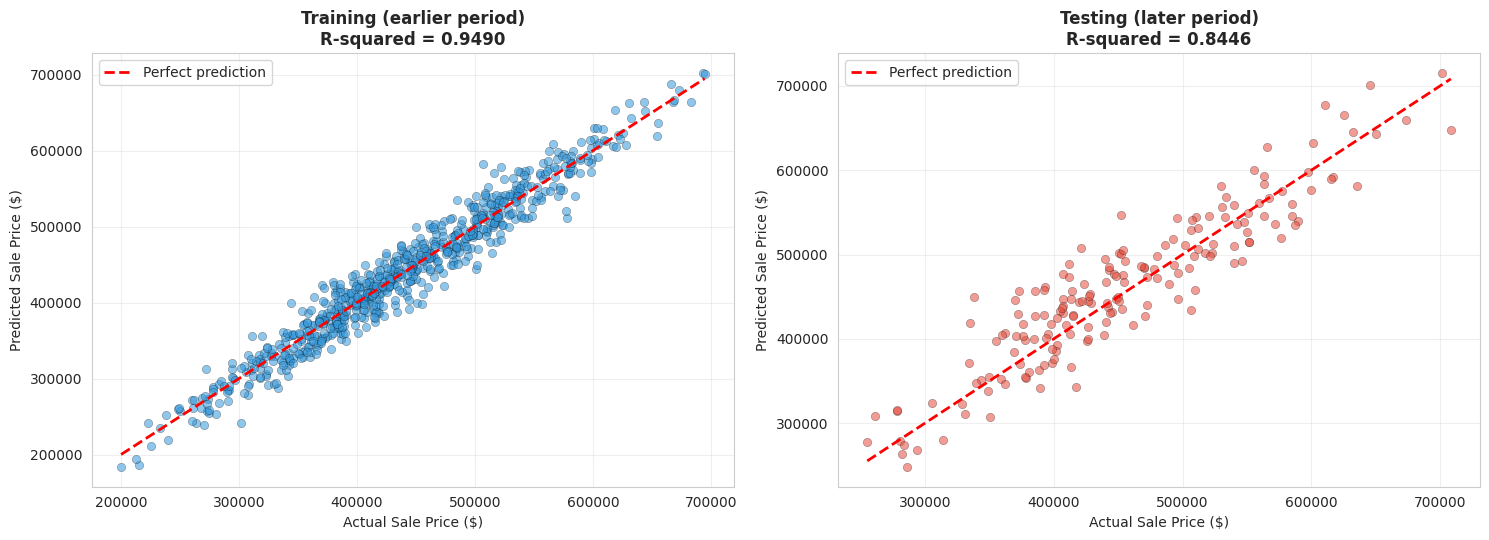

In [18]:
# Cross-validation on the full sample. More stable than a single split, which
# matters a great deal on a few hundred sales.
cv = KFold(n_splits=5, shuffle=True, random_state=CONFIG["random_state"])
cv_scores = cross_val_score(xgb.XGBRegressor(**xgb_params), X, y, cv=cv, scoring="r2")
print(f"Cross-validated R-squared: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Per fold: {np.round(cv_scores, 4).tolist()}")
print("\nNote these folds are shuffled, so they measure fit quality, not the")
print("forward-looking accuracy the time-based split above measures. Report both.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (yt, yp, label, color, r2v) in zip(axes, [
        (y_train, y_train_pred, "Training (earlier period)", "#3498db", r2_train),
        (y_test,  y_test_pred,  "Testing (later period)",    "#e74c3c", r2_test)]):
    ax.scatter(yt, yp, alpha=0.55, color=color, edgecolors="black", linewidth=0.3)
    ax.plot([yt.min(), yt.max()], [yt.min(), yt.max()], "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Actual Sale Price ($)"); ax.set_ylabel("Predicted Sale Price ($)")
    ax.set_title(f"{label}\nR-squared = {r2v:.4f}", fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Step 10 — THE ADJUSTMENT GRID, with confidence intervals

This replaces the regression coefficient table, and it answers the same question. For every
closed sale in the sample: predict it, add one unit of the characteristic, hold everything
else fixed, predict again, and record the difference. The average of those differences is
the market-derived adjustment.

**How to read the columns:**

- **Adjustment** — the average dollar effect of one step. Area features step by 100 sq ft
  (1,000 for lot) because one square foot is not a unit anyone adjusts by.
- **95% interval** — percentile bootstrap over sales. Same decision rule as the regression
  notebook's confidence interval: **if it spans zero, the data has not shown the effect
  differs from no effect, and it does not go in the grid.**
- **Share_Responsive** — the fraction of sales where the prediction moved at all. Trees are
  step functions; below about 25% the average is carried by a minority of records.
- **OLS_Crosscheck** — the same adjustment from an ordinary least squares fit. Where the two
  agree, you have a genuinely robust number. Where they diverge sharply, something is wrong
  and the diagnostics are the place to look.

In [19]:
# Refit on the FULL sample for the final grid. The time-based split validated that
# the model generalizes; now every available sale contributes to the estimates.
final_model = xgb.XGBRegressor(**xgb_params).fit(X, y)

grid = adjustment_grid(final_model, X, n_boot=CONFIG["n_bootstrap"],
                       random_state=CONFIG["random_state"])

# OLS cross-check: the coefficient scaled to the same step size
ols = LinearRegression().fit(X, y)
ols_by_feat = dict(zip(X.columns, ols.coef_))
grid["OLS_Crosscheck"] = [ols_by_feat[f] * s for f, s in zip(grid["Feature"], grid["Step"])]

print("=" * 108)
print("MARKET-DERIVED ADJUSTMENT GRID")
print("=" * 108)
print(f"Sample: {len(X)} closed sales   |   Model: XGBoost (monotone-constrained)")
print(f"Full-sample R-squared: {final_model.score(X, y):.4f}\n")

show = grid[["Unit", "Adjustment", "CI_Lower_95", "CI_Upper_95",
             "Share_Responsive", "OLS_Crosscheck", "Use_In_Grid"]].copy()
for c in ["Adjustment", "CI_Lower_95", "CI_Upper_95", "OLS_Crosscheck"]:
    show[c] = show[c].map(lambda v: f"${v:,.0f}")
show["Share_Responsive"] = grid["Share_Responsive"].map(lambda v: f"{v:.0%}")
print(show.to_string(index=False))

print("\n" + "=" * 108)
print("DEFENSIBLE ADJUSTMENTS")
print("=" * 108)
supported = grid[grid["Use_In_Grid"].str.startswith("YES")]
if len(supported) == 0:
    print("None of the characteristics produced a statistically supported adjustment.")
    print("This almost always means the sample is too small, too narrow, or both.")
    print("Revisit Diagnostic A before drawing any conclusion.")
else:
    for _, r in supported.iterrows():
        print(f"  ${r['Adjustment']:>11,.0f}   {r['Unit']:<36s} "
              f"(95% CI ${r['CI_Lower_95']:,.0f} to ${r['CI_Upper_95']:,.0f})")

rejected = grid[~grid["Use_In_Grid"].str.startswith("YES")]
if len(rejected):
    print("\nNOT SUPPORTED -- do not carry these into a grid:")
    for _, r in rejected.iterrows():
        print(f"  {r['Unit']:<40s} {r['Use_In_Grid']}")

MARKET-DERIVED ADJUSTMENT GRID
Sample: 900 closed sales   |   Model: XGBoost (monotone-constrained)
Full-sample R-squared: 0.9440

                              Unit Adjustment CI_Lower_95 CI_Upper_95 Share_Responsive OLS_Crosscheck     Use_In_Grid
  per 100 sq ft of above-grade GLA    $12,718     $12,181     $13,298              99%        $12,162 YES - supported
                    per garage bay     $9,252      $8,693      $9,825              69%        $10,776 YES - supported
                 per full bathroom     $7,420      $7,078      $7,784              76%         $8,294 YES - supported
            per 1,000 sq ft of lot     $4,958      $4,630      $5,289              94%         $3,064 YES - supported
per 100 sq ft of finished basement     $4,741      $4,461      $5,062              97%         $4,239 YES - supported
                 per half bathroom     $4,688      $4,397      $4,986              66%         $5,309 YES - supported
                     per fireplace     $4,3

XGBOOST vs OLS -- AGREEMENT CHECK
           Feature                               Unit Adjustment OLS_Crosscheck Ratio
          gla_sqft   per 100 sq ft of above-grade GLA    $12,718        $12,162 1.05x
     garage_spaces                     per garage bay     $9,252        $10,776 0.86x
        baths_full                  per full bathroom     $7,420         $8,294 0.89x
          lot_sqft             per 1,000 sq ft of lot     $4,958         $3,064 1.62x
     bsmt_fin_sqft per 100 sq ft of finished basement     $4,741         $4,239 1.12x
        baths_half                  per half bathroom     $4,688         $5,309 0.88x
        fireplaces                      per fireplace     $4,330         $2,827 1.53x
months_since_start      per month (market conditions)     $1,869         $1,300 1.44x
          bedrooms                        per bedroom    $-1,806        $-1,694 1.07x
       age_at_sale                    per year of age    $-1,531          $-903 1.69x

A ratio near 1.0 me

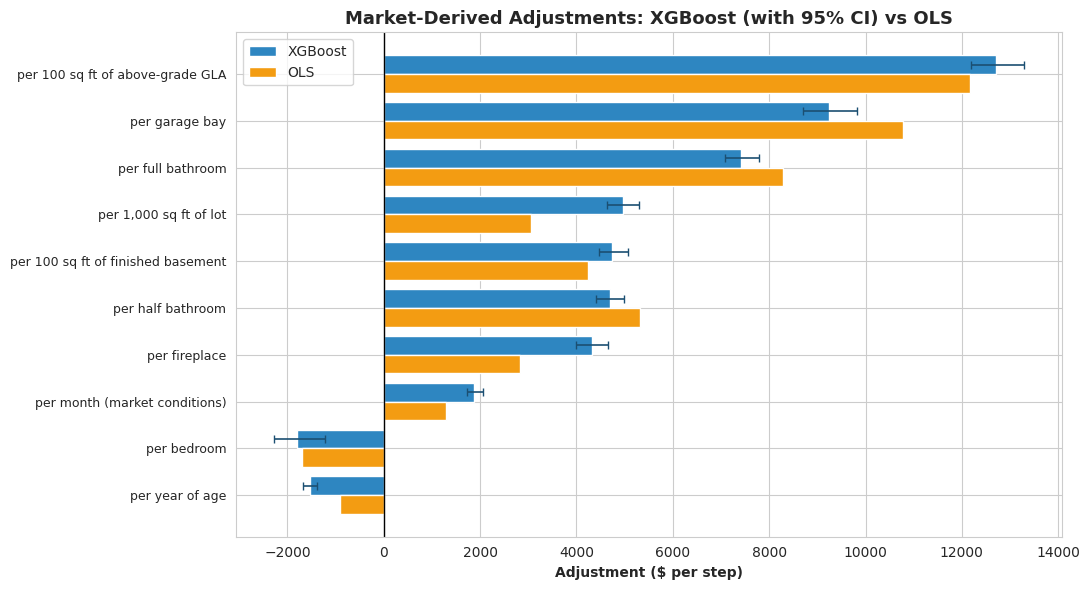

In [20]:
# Where do XGBoost and OLS disagree? Divergence is a signal, not a nuisance.
cmp_df = grid[["Feature", "Unit", "Adjustment", "OLS_Crosscheck"]].copy()
cmp_df["Ratio"] = cmp_df["Adjustment"] / cmp_df["OLS_Crosscheck"].replace(0, np.nan)

print("XGBOOST vs OLS -- AGREEMENT CHECK")
print("=" * 88)
print(cmp_df.assign(
    Adjustment=lambda d: d["Adjustment"].map("${:,.0f}".format),
    OLS_Crosscheck=lambda d: d["OLS_Crosscheck"].map("${:,.0f}".format),
    Ratio=lambda d: d["Ratio"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}x"),
).to_string(index=False))

print("\nA ratio near 1.0 means both models found the same effect and you can")
print("defend the number. Far from 1.0 means the effect is either nonlinear")
print("(the tree found structure OLS assumed away) or unstable (the feature is")
print("correlated with another and the two models split the credit differently).")
print("Check the correlation matrix in Step 7 to tell those two cases apart.")

fig, ax = plt.subplots(figsize=(11, 6))
ypos = np.arange(len(grid))
ax.barh(ypos - 0.2, grid["Adjustment"], height=0.4, label="XGBoost", color="#2E86C1",
        xerr=[grid["Adjustment"] - grid["CI_Lower_95"], grid["CI_Upper_95"] - grid["Adjustment"]],
        error_kw=dict(ecolor="#1B4F72", lw=1.2, capsize=3))
ax.barh(ypos + 0.2, grid["OLS_Crosscheck"], height=0.4, label="OLS", color="#F39C12")
ax.set_yticks(ypos); ax.set_yticklabels(grid["Unit"], fontsize=9)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Adjustment ($ per step)", fontweight="bold")
ax.set_title("Market-Derived Adjustments: XGBoost (with 95% CI) vs OLS",
             fontsize=13, fontweight="bold")
ax.legend(); ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Step 11 — Location adjustments

Every location is switched on for every sale in turn, and the price difference relative to
the baseline location is averaged. This is the tree-model form of the `loc_` dummy
coefficients from the regression notebook.

In [21]:
loc_adj = location_effects(final_model, X, baseline_loc)

print("LOCATION ADJUSTMENTS")
print("=" * 70)
print(f"Baseline location: {baseline_loc}\n")
if len(loc_adj) == 0:
    print("Only one location level in this sample; no location adjustment estimated.")
else:
    for _, r in loc_adj.iterrows():
        print(f"  ${r['Adjustment_vs_Baseline']:>12,.0f}   {r['Location']} vs {baseline_loc}")
    print("\nThese absorb everything that varies by area and is not otherwise in the")
    print("model: school district, proximity, lot character, neighbourhood appeal.")

LOCATION ADJUSTMENTS
Baseline location: Carmel

  $      11,516   Zionsville vs Carmel
  $     -21,764   Fishers vs Carmel
  $     -36,563   Westfield vs Carmel

These absorb everything that varies by area and is not otherwise in the
model: school district, proximity, lot character, neighbourhood appeal.


## Step 12 — Relative importance (permutation importance)

This replaces the standardized coefficients. Shuffle one feature at a time on the held-out
sales and measure how much accuracy degrades. Measured on data the model has not seen, and
unlike the tree's built-in `feature_importances_` it is not biased toward high-cardinality
features.

Read this column for **ranking**. Read the adjustment grid for the actual **dollar** figure.
They answer different questions and a feature can be high on one and low on the other.

PERMUTATION IMPORTANCE (measured on the held-out later period)
Drop in R-squared when each feature is randomly shuffled:

           Feature  Importance  Std_Dev
          gla_sqft        1.41     0.08
       age_at_sale        0.12     0.01
          lot_sqft        0.09     0.01
     bsmt_fin_sqft        0.08     0.01
     loc_Westfield        0.06     0.01
        baths_full        0.03     0.00
          bedrooms        0.02     0.00
     garage_spaces        0.02     0.00
    loc_Zionsville        0.02     0.00
       loc_Fishers        0.01     0.00
        baths_half        0.01     0.00
months_since_start        0.01     0.00
        fireplaces        0.00     0.00

Features at or below zero contribute nothing the model can use.


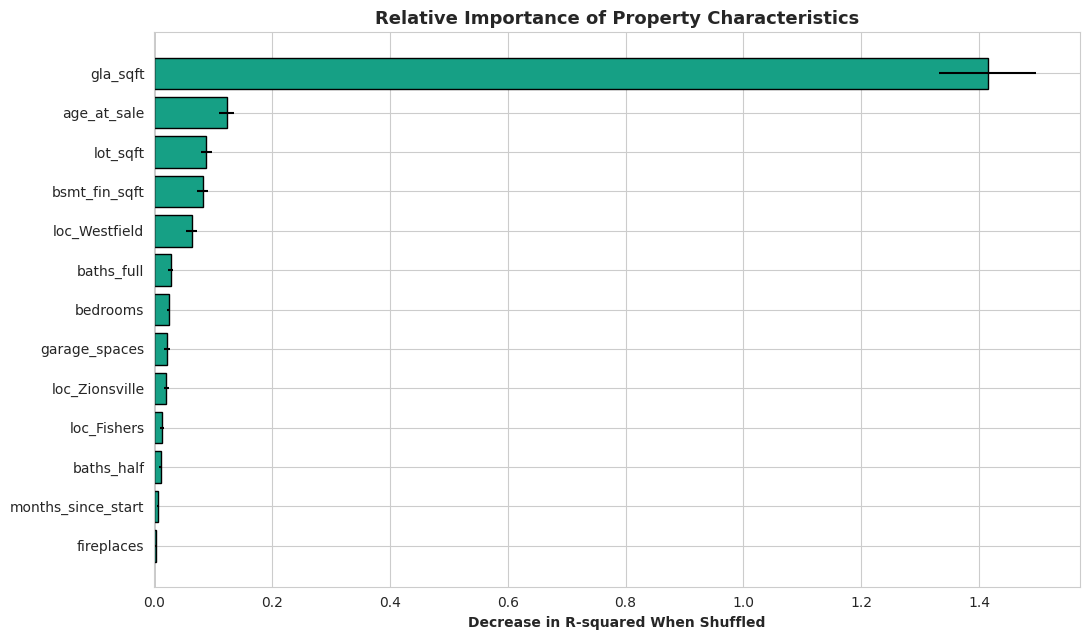

In [22]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=30,
                              random_state=CONFIG["random_state"], scoring="r2")
perm_df = pd.DataFrame({
    "Feature": X.columns, "Importance": perm.importances_mean, "Std_Dev": perm.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("PERMUTATION IMPORTANCE (measured on the held-out later period)")
print("=" * 80)
print("Drop in R-squared when each feature is randomly shuffled:\n")
print(perm_df.round(4).to_string(index=False))
print("\nFeatures at or below zero contribute nothing the model can use.")

plt.figure(figsize=(11, 6.5))
plt.barh(perm_df["Feature"], perm_df["Importance"], xerr=perm_df["Std_Dev"],
         color="#16A085", edgecolor="black")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Decrease in R-squared When Shuffled", fontweight="bold")
plt.title("Relative Importance of Property Characteristics", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

---
## Step 13 — Model 2: Random Forest (the challenger)

Both models are tree ensembles and neither assumes a fixed dollar adjustment per unit, so
this is not the linear-versus-nonlinear check the regression notebook was running. It is a
straight bake-off on the same held-out period, and the interesting outcome is a *small*
gap.

**How to read the result:**
- **XGBoost clearly ahead** — boosting is finding structure the forest's independent trees
  miss. Ship XGBoost.
- **Random Forest clearly ahead** — usually a sign the sample is small enough that boosting
  is overfitting. Forests average independent trees and are more stable on small data. Take
  it seriously; a simpler, more stable model that you can defend beats a fragile one.
- **Comparable** — the choice is not doing much work. Ship XGBoost for the monotone
  constraints, which the forest cannot enforce, and say in your write-up that the gap was
  not the deciding factor. That is a better answer in an interview than inventing one.

In [23]:
print("=" * 80)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 80)

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,      # guards against memorizing individual sales
    random_state=CONFIG["random_state"],
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_test_pred_rf = rf_model.predict(X_test)

r2_test_rf   = r2_score(y_test, y_test_pred_rf)
mae_test_rf  = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = float(np.sqrt(mean_squared_error(y_test, y_test_pred_rf)))

print(f"\nTest R-squared:            {r2_test_rf:.4f}")
print(f"Test Mean Absolute Error:  ${mae_test_rf:,.0f}")
print(f"Test RMSE:                 ${rmse_test_rf:,.0f}")

MODEL 2: RANDOM FOREST REGRESSOR



Test R-squared:            0.7822
Test Mean Absolute Error:  $35,319
Test RMSE:                 $43,091


MODEL PERFORMANCE COMPARISON (held-out later period)
                Metric XGBoost Random Forest
      R-squared (test)  0.8446        0.7822
            MAE (test) $29,735       $35,319
           RMSE (test) $36,403       $43,091
MAE as % of mean price   6.54%         7.77%

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
XGBoost outperforms Random Forest by 0.062 R-squared. Boosting is finding structure the forest misses. XGBoost is the champion.



ADJUSTMENT AGREEMENT BETWEEN THE TWO MODELS
                              Unit Adjustment_XGB Adjustment_RF Difference
  per 100 sq ft of above-grade GLA        $12,718       $11,036     $1,682
                    per garage bay         $9,252        $2,273     $6,979
                 per full bathroom         $7,420        $1,808     $5,611
            per 1,000 sq ft of lot         $4,958        $1,977     $2,981
per 100 sq ft of finished basement         $4,741        $2,330     $2,411
                 per half bathroom         $4,688        $1,052     $3,636
                     per fireplace         $4,330          $789     $3,541
     per month (market conditions)         $1,869          $814     $1,055
                       per bedroom        $-1,806         $-387    $-1,419
                   per year of age        $-1,531         $-517    $-1,014

EXPECT the Random Forest column to be SMALLER, often much smaller. That is
a property of the estimator, not a contradiction. Each

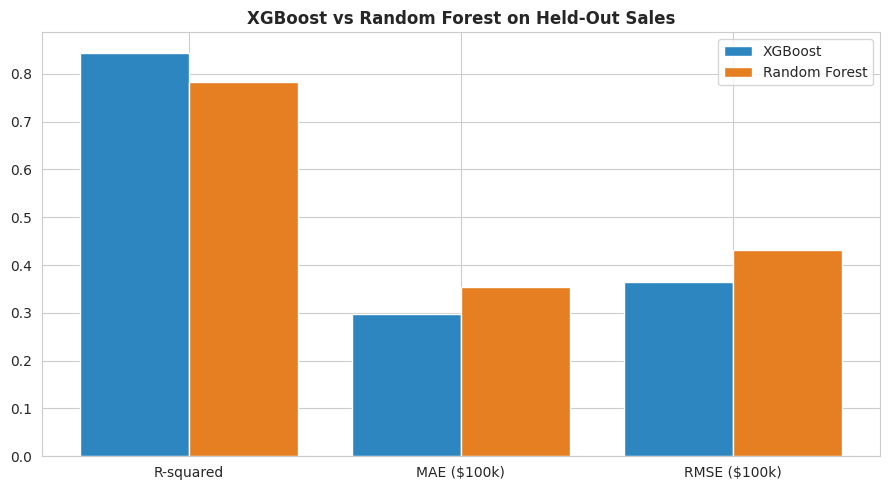

In [24]:
comparison = pd.DataFrame({
    "Metric": ["R-squared (test)", "MAE (test)", "RMSE (test)", "MAE as % of mean price"],
    "XGBoost":       [f"{r2_test:.4f}", f"${mae_test:,.0f}", f"${rmse_test:,.0f}",
                      f"{mae_test/y_test.mean()*100:.2f}%"],
    "Random Forest": [f"{r2_test_rf:.4f}", f"${mae_test_rf:,.0f}", f"${rmse_test_rf:,.0f}",
                      f"{mae_test_rf/y_test.mean()*100:.2f}%"],
})

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON (held-out later period)")
print("=" * 80)
print(comparison.to_string(index=False))

gap = r2_test - r2_test_rf
print("\n" + "-" * 80)
print("INTERPRETATION")
print("-" * 80)
if gap > 0.05:
    verdict = (f"XGBoost outperforms Random Forest by {gap:.3f} R-squared. Boosting is "
               "finding structure the forest misses. XGBoost is the champion.")
elif gap < -0.05:
    verdict = (f"Random Forest outperforms XGBoost by {abs(gap):.3f} R-squared, which "
               "usually means the sample is small enough that boosting is overfitting. "
               "Reduce n_estimators and max_depth, or ship the forest and lose the "
               "monotone constraints.")
else:
    verdict = (f"The two perform comparably ({gap:+.3f} R-squared). XGBoost is shipped for "
               "its monotone constraints, which keep the adjustment grid coherent, not "
               "because it predicts better.")
print(verdict)

# Compare the ADJUSTMENTS, not just the accuracy. Two models can predict equally
# well and still disagree about what a bathroom is worth -- and the adjustment is
# what you are actually shipping.
rf_grid = adjustment_grid(rf_model, X_train, n_boot=150, random_state=CONFIG["random_state"])
side = grid[["Feature", "Unit", "Adjustment"]].merge(
    rf_grid[["Feature", "Adjustment"]], on="Feature", suffixes=("_XGB", "_RF"))
side["Difference"] = side["Adjustment_XGB"] - side["Adjustment_RF"]

print("\nADJUSTMENT AGREEMENT BETWEEN THE TWO MODELS")
print("=" * 88)
print(side.assign(
    Adjustment_XGB=lambda d: d["Adjustment_XGB"].map("${:,.0f}".format),
    Adjustment_RF=lambda d: d["Adjustment_RF"].map("${:,.0f}".format),
    Difference=lambda d: d["Difference"].map("${:,.0f}".format),
)[["Unit", "Adjustment_XGB", "Adjustment_RF", "Difference"]].to_string(index=False))
print("\nEXPECT the Random Forest column to be SMALLER, often much smaller. That is")
print("a property of the estimator, not a contradiction. Each tree in a forest sees")
print("a bootstrap sample and a random subset of features, so a large share of trees")
print("never split on any given feature at all. Averaging over those trees dilutes")
print("the effect toward zero. Boosting adds trees that correct the previous ones'")
print("errors, so a real effect keeps getting reinforced rather than averaged away.")
print("\nWhat to actually read here: the RANKING and the SIGNS should match. If the")
print("two models disagree about which characteristics matter most, or about the")
print("direction of one, that is a genuine problem. Magnitudes are compared against")
print("the OLS cross-check in Step 10, not against the forest.")

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(3)
ax.bar(xpos - 0.2, [r2_test, mae_test/1e5, rmse_test/1e5], 0.4, label="XGBoost", color="#2E86C1")
ax.bar(xpos + 0.2, [r2_test_rf, mae_test_rf/1e5, rmse_test_rf/1e5], 0.4, label="Random Forest", color="#E67E22")
ax.set_xticks(xpos); ax.set_xticklabels(["R-squared", "MAE ($100k)", "RMSE ($100k)"])
ax.set_title("XGBoost vs Random Forest on Held-Out Sales", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

---
## Step 14 — Log-price model: percentage adjustments

Appraisers often think in percentages: "a full bath is worth about 3% of value." Modeling
the natural log of price gives effects that convert directly into percentages.

This form also handles a standing objection to any dollar grid: in dollar terms a bathroom
is worth more in a $900k house than a $300k house, which violates the constant-adjustment
assumption. In percentage terms the effect is often far more stable across price tiers.

In [25]:
y_log = np.log(y)
log_model = xgb.XGBRegressor(**xgb_params).fit(X, y_log)

pct = percent_grid(log_model, X, float(y.mean()), n_boot=CONFIG["n_bootstrap"],
                   random_state=CONFIG["random_state"])

print("=" * 96)
print("LOG-PRICE MODEL -- PERCENTAGE ADJUSTMENTS")
print("=" * 96)
print(f"R-squared (log scale): {log_model.score(X, y_log):.4f}")
print(f"Mean sale price used for dollar conversion: ${y.mean():,.0f}\n")

print(pct.assign(
    Percent_Effect=lambda d: d["Percent_Effect"].map("{:.2f}%".format),
    Pct_CI_Lower=lambda d: d["Pct_CI_Lower"].map("{:.2f}%".format),
    Pct_CI_Upper=lambda d: d["Pct_CI_Upper"].map("{:.2f}%".format),
    Dollar_At_Mean_Price=lambda d: d["Dollar_At_Mean_Price"].map("${:,.0f}".format),
)[["Unit", "Percent_Effect", "Pct_CI_Lower", "Pct_CI_Upper", "Dollar_At_Mean_Price"]].to_string(index=False))

print("\n" + "-" * 96)
print("Reading this table: a Percent_Effect of 3.0 for full baths means each")
print("additional full bathroom is associated with a 3% higher sale price.")
print("Compare Dollar_At_Mean_Price against the Step 10 grid -- close agreement")
print("between the two models is good evidence the adjustment is real.")

check = grid[["Feature", "Unit", "Adjustment"]].merge(
    pct[["Feature", "Dollar_At_Mean_Price"]], on="Feature")
check["Agreement"] = np.where(
    (check["Adjustment"].abs() > 500) &
    ((check["Dollar_At_Mean_Price"] / check["Adjustment"]).between(0.6, 1.6)),
    "consistent", "divergent")
print("\nCROSS-MODEL AGREEMENT (dollar grid vs log model)")
print(check.assign(
    Adjustment=lambda d: d["Adjustment"].map("${:,.0f}".format),
    Dollar_At_Mean_Price=lambda d: d["Dollar_At_Mean_Price"].map("${:,.0f}".format),
)[["Unit", "Adjustment", "Dollar_At_Mean_Price", "Agreement"]].to_string(index=False))

LOG-PRICE MODEL -- PERCENTAGE ADJUSTMENTS
R-squared (log scale): 0.9441
Mean sale price used for dollar conversion: $442,814

                              Unit Percent_Effect Pct_CI_Lower Pct_CI_Upper Dollar_At_Mean_Price
  per 100 sq ft of above-grade GLA          3.02%        2.87%        3.17%              $13,363
                    per garage bay          2.26%        2.11%        2.40%               $9,986
                 per full bathroom          1.77%        1.68%        1.85%               $7,818
per 100 sq ft of finished basement          1.16%        1.09%        1.24%               $5,115
            per 1,000 sq ft of lot          1.15%        1.07%        1.22%               $5,078
                     per fireplace          1.09%        1.00%        1.17%               $4,813
                 per half bathroom          1.05%        0.99%        1.12%               $4,668
     per month (market conditions)          0.50%        0.46%        0.55%               $2,198
 

---
## Step 15 — Value a subject property

The model applied in the direction an appraiser actually uses it: describe a subject
property, get an indicated value plus what drives it.

This uses `build_serving_row` — **the exact function the deployed API calls**. If the
number you get here does not match what the API returns for the same subject after
deployment, you have skew, and this cell is where you catch it.

In [26]:
# Build the metadata the serving path needs (the same dict written to S3 in Step 16)
serving_meta = {
    "feature_names": list(X.columns),
    "feature_medians": X.median().to_dict(),
    "anchor_date": meta_bits["anchor_date"],
    "baseline_location": baseline_loc,
    "location_levels": location_levels,
}

subject_property = {
    "main_sqft": 1800,
    "upper_sqft": 900,
    "bsmt_fin_sqft": 800,
    "bedrooms": 4,
    "baths_full": 3,
    "baths_half": 1,
    "garage_spaces": 3,
    "fireplaces": 1,
    "lot_sqft": 12000,
    "year_built": 2005,
    "location": location_levels[-1],
    "effective_date": str(pd.Timestamp(data["close_date"].max()).date()),
}

x_subject = build_serving_row(subject_property, serving_meta)
indicated = float(final_model.predict(x_subject)[0])

print("=" * 80)
print("SUBJECT PROPERTY VALUATION")
print("=" * 80)
print("\nSubject characteristics:")
for k, v in subject_property.items():
    print(f"   {k:20s} {v}")

print(f"\nINDICATED VALUE:  ${indicated:,.0f}")
print(f"Supported range:  ${indicated - mae_test:,.0f} to ${indicated + mae_test:,.0f}")
print(f"                  (point estimate +/- test-set MAE of ${mae_test:,.0f})")

print("\n" + "-" * 80)
print("WHAT DRIVES THIS VALUE")
print("-" * 80)
print("Change in indicated value if each characteristic were reset to the sample median:\n")
cb = contribution_breakdown(final_model, x_subject, X)
print(cb.assign(
    Contribution=lambda d: d["Contribution"].map("${:,.0f}".format)
).to_string(index=False))
print("\nThese do not sum to the total. A boosted model is not additive, so the")
print("parts depend on the order you remove them in. Read them as magnitudes.")

SUBJECT PROPERTY VALUATION

Subject characteristics:
   main_sqft            1800
   upper_sqft           900
   bsmt_fin_sqft        800
   bedrooms             4
   baths_full           3
   baths_half           1
   garage_spaces        3
   fireplaces           1
   lot_sqft             12000
   year_built           2005
   location             Zionsville
   effective_date       2025-08-07

INDICATED VALUE:  $657,153
Supported range:  $627,418 to $686,888
                  (point estimate +/- test-set MAE of $29,735)

--------------------------------------------------------------------------------
WHAT DRIVES THIS VALUE
--------------------------------------------------------------------------------
Change in indicated value if each characteristic were reset to the sample median:

           Feature  Subject_Value  Sample_Median Contribution
          gla_sqft       2,700.00       1,961.00     $114,762
    loc_Zionsville           1.00           0.00      $45,326
     bsmt_fin_sqft

In [27]:
print("=" * 80)
print("PAIRED SCENARIO ANALYSIS")
print("=" * 80)
print("Identical properties differing in exactly one characteristic.\n")

for feat, values in [("garage_spaces", [1, 2, 3]),
                     ("baths_full", [2, 3, 4]),
                     ("bedrooms", [3, 4, 5]),
                     ("gla_sqft", [2500, 2700, 2900])]:
    print(f"--- {UNIT_LABELS.get(feat, feat).upper()} ---")
    sc = compare_scenarios(final_model, x_subject, feat, values)
    print(sc.assign(
        Indicated_Value=lambda d: d["Indicated_Value"].map("${:,.0f}".format),
        Difference=lambda d: d["Difference"].map(lambda v: "-" if pd.isna(v) else f"${v:,.0f}"),
    ).to_string(index=False))
    print()

print("This is the regression equivalent of a matched-pairs analysis, except every")
print("other variable is held constant by construction rather than by hoping two")
print("comparables happen to be otherwise identical.")

PAIRED SCENARIO ANALYSIS
Identical properties differing in exactly one characteristic.

--- PER GARAGE BAY ---
 garage_spaces Indicated_Value Difference
             1        $641,338          -
             2        $648,786     $7,448
             3        $657,153     $8,367

--- PER FULL BATHROOM ---
 baths_full Indicated_Value Difference
          2        $642,612          -
          3        $657,153    $14,541
          4        $670,192    $13,039

--- PER BEDROOM ---
 bedrooms Indicated_Value Difference
        3        $650,243          -
        4        $657,153     $6,910
        5        $669,097    $11,944

--- PER SQ FT OF ABOVE-GRADE GLA ---
 gla_sqft Indicated_Value Difference
     2500        $639,118          -
     2700        $657,153    $18,035
     2900        $688,657    $31,504

This is the regression equivalent of a matched-pairs analysis, except every
other variable is held constant by construction rather than by hoping two
comparables happen to be otherwi

---
## Step 16 — Export the artifacts

**Leave the notebook with everything in S3 and never open it again for training.**

Five artifacts, and each one exists for a reason:

| File | Why |
|---|---|
| `model.json` | The champion. `save_model`, **never pickle** — pickle breaks across XGBoost and Python versions and you will hit that. |
| `model_log.json` | The log-price model, so the API can serve percentage adjustments. |
| `metadata.json` | Version, train date, **feature names in order**, medians, metrics, both models' scores, diagnostics. The feature order is what stops serving skew. |
| `adjustment_grid.json` | The grid, precomputed. The bootstrap is hundreds of full-sample predictions per feature; that is seconds of CPU on a 0.25 vCPU Fargate task and it does not change between deployments. Compute once, ship as an artifact. |
| `reference.parquet` | Snapshot of the training features. **Phase 4's drift baseline.** Save it now — retrofitting it later means retraining to get a matching snapshot. |

In [28]:
version   = CONFIG["model_version"]
local_dir = Path(CONFIG["local_artifacts"]) / version
local_dir.mkdir(parents=True, exist_ok=True)

# 1 + 2 -- models. save_model(), NOT pickle.
final_model.save_model(local_dir / "model.json")
log_model.save_model(local_dir / "model_log.json")

# 3 -- metadata. feature_names ORDER is the anti-skew contract with the API.
metadata = {
    "model_version": version,
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "source_file": CONFIG["excel_path"],
    "synthetic_data": USING_SYNTHETIC,
    "n_training_sales": int(len(X)),
    "date_min": str(data["close_date"].min().date()),
    "date_max": str(data["close_date"].max().date()),
    "split_date": str(pd.Timestamp(cutoff).date()),
    "anchor_date": meta_bits["anchor_date"],
    "concessions_netted": bool(CONFIG["net_concessions"]),
    "mean_price": float(y.mean()),
    "feature_names": list(X.columns),           # ORDER MATTERS
    "feature_medians": {k: float(v) for k, v in X.median().items()},
    "location_levels": location_levels,
    "baseline_location": baseline_loc,
    "monotone_constraints": {c: int(m) for c, m in zip(X.columns, mono_tuple)},
    "xgb_params": {k: (list(v) if isinstance(v, tuple) else v)
                   for k, v in xgb_params.items()},
    "metrics": {
        "r2_train": float(r2_train), "mae_train": float(mae_train),
        "r2_test": float(r2_test), "mae_test": float(mae_test), "rmse_test": float(rmse_test),
        "cv_r2_mean": float(cv_scores.mean()), "cv_r2_std": float(cv_scores.std()), "cv_folds": 5,
    },
    "model_comparison": {
        "xgboost": {"r2": float(r2_test), "mae": float(mae_test), "rmse": float(rmse_test),
                    "mae_pct": float(mae_test / y_test.mean() * 100)},
        "random_forest": {"r2": float(r2_test_rf), "mae": float(mae_test_rf),
                          "rmse": float(rmse_test_rf),
                          "mae_pct": float(mae_test_rf / y_test.mean() * 100)},
        "verdict": verdict,
    },
    "data_diagnostics": DIAGNOSTICS,
}
(local_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))

# 4 -- precomputed adjustment grid, in the shape the API returns it
def _rows(df, cols):
    return [{k.lower(): (v.item() if hasattr(v, "item") else v)
             for k, v in r[cols].items()} for _, r in df.iterrows()]

grid_artifact = {
    "dollar": _rows(grid, ["Feature", "Unit", "Step", "Adjustment", "CI_Lower_95",
                           "CI_Upper_95", "Share_Responsive", "Use_In_Grid"]),
    "percent": _rows(pct, ["Feature", "Unit", "Step", "Percent_Effect",
                           "Pct_CI_Lower", "Pct_CI_Upper", "Dollar_At_Mean_Price"]),
    "location": _rows(loc_adj, ["Location", "Adjustment_vs_Baseline"]) if len(loc_adj) else [],
}
(local_dir / "adjustment_grid.json").write_text(json.dumps(grid_artifact, indent=2))

# 5 -- drift reference. Column order MUST match metadata["feature_names"];
#      app/model.py refuses to start if it does not.
X.to_parquet(local_dir / "reference.parquet", index=False)

print("ARTIFACTS WRITTEN")
print("=" * 80)
for p in sorted(local_dir.iterdir()):
    print(f"  {p.name:24s} {p.stat().st_size/1024:8.1f} KB")
print(f"\nLocal path: {local_dir.resolve()}")
if USING_SYNTHETIC:
    print("\nWARNING: these artifacts were trained on SYNTHETIC data.")
    print("They are fine for wiring up Phases 2-4 and worthless for anything else.")

ARTIFACTS WRITTEN
  adjustment_grid.json          6.1 KB
  metadata.json                 2.7 KB
  model.json                 1241.9 KB
  model_log.json             1275.1 KB
  reference.parquet            23.0 KB

Local path: /home/claude/build/appraisal-api/notebooks/artifacts/v1

They are fine for wiring up Phases 2-4 and worthless for anything else.


In [29]:
# Upload to S3. Set CONFIG["s3_bucket"] to enable.
if CONFIG["s3_bucket"]:
    import boto3
    s3 = boto3.client("s3", region_name=CONFIG["aws_region"])
    prefix = f"{CONFIG['s3_prefix']}/{version}"
    for p in sorted(local_dir.iterdir()):
        s3.upload_file(str(p), CONFIG["s3_bucket"], f"{prefix}/{p.name}")
        print(f"  uploaded s3://{CONFIG['s3_bucket']}/{prefix}/{p.name}")
    print(f"\nMODEL_BUCKET={CONFIG['s3_bucket']}")
    print(f"MODEL_PREFIX={prefix}")
    print("\nThose two values go into the ECS task definition in Phase 3.")
else:
    print("CONFIG['s3_bucket'] is None -- skipping upload.")
    print("The API can run against the local artifacts directory for Phase 2:")
    print(f"   docker run -e LOCAL_MODEL_DIR=/app/artifacts -v {local_dir.resolve()}:/app/artifacts:ro ...")

CONFIG['s3_bucket'] is None -- skipping upload.
The API can run against the local artifacts directory for Phase 2:
   docker run -e LOCAL_MODEL_DIR=/app/artifacts -v /home/claude/build/appraisal-api/notebooks/artifacts/v1:/app/artifacts:ro ...


## Step 17 — Done-when check

From the Phase 1 plan: *a fresh kernel can load `model.json`, run the feature function on
one raw row, and produce a prediction matching what you saw during training.*

The cell below does exactly that — reloads the model from disk as a **new object**, rebuilds
the subject row through the shared serving function, and asserts the prediction matches. If
this passes, Phase 1 is complete and you can start Phase 2.

In [30]:
print("PHASE 1 DONE-WHEN CHECK")
print("=" * 80)

reloaded = xgb.XGBRegressor()
reloaded.load_model(local_dir / "model.json")

meta_from_disk = json.loads((local_dir / "metadata.json").read_text())
ref_from_disk  = pd.read_parquet(local_dir / "reference.parquet")

row_again = build_serving_row(subject_property, meta_from_disk)
pred_again = float(reloaded.predict(row_again)[0])

checks = [
    ("model.json reloads", True),
    ("feature order matches reference.parquet",
     list(ref_from_disk.columns) == meta_from_disk["feature_names"]),
    ("serving row matches training column order",
     list(row_again.columns) == list(X.columns)),
    ("reloaded prediction matches in-memory prediction",
     abs(pred_again - indicated) < 1.0),
    ("adjustment grid artifact is non-empty",
     len(json.loads((local_dir / "adjustment_grid.json").read_text())["dollar"]) > 0),
]

for label, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {label}")

print(f"\nIn-memory prediction: ${indicated:,.2f}")
print(f"Reloaded prediction:  ${pred_again:,.2f}")
print(f"Difference:           ${abs(pred_again - indicated):,.6f}")

if all(ok for _, ok in checks):
    print("\n" + "=" * 80)
    print("PHASE 1 COMPLETE. Artifacts are versioned and reloadable.")
    print("Next: set MODEL_BUCKET / MODEL_PREFIX in the API and build the container.")
    print("=" * 80)
else:
    print("\nOne or more checks FAILED. Do not proceed to Phase 2 -- fix these first.")

PHASE 1 DONE-WHEN CHECK


  [PASS]  model.json reloads
  [PASS]  feature order matches reference.parquet
  [PASS]  serving row matches training column order
  [PASS]  reloaded prediction matches in-memory prediction
  [PASS]  adjustment grid artifact is non-empty

In-memory prediction: $657,153.00
Reloaded prediction:  $657,153.00
Difference:           $0.000000

PHASE 1 COMPLETE. Artifacts are versioned and reloadable.
Next: set MODEL_BUCKET / MODEL_PREFIX in the API and build the container.


---
# How to read the results

### The two square-foot rates are not interchangeable

The **average** rate (sale price divided by size) includes the land, the site improvements,
and every amenity, all spread across the square footage. The **marginal** rate from the
model is what the market pays for one *additional* square foot with everything else
unchanged. The marginal rate is almost always the lower of the two, and it is the correct
basis for a size adjustment between comparables. Using the average rate to adjust for a
300 sq ft difference systematically over-adjusts.

### A near-zero bedroom adjustment is a finding, not a failure

Once square footage is in the model, the bedroom effect measures what the market pays for
*partitioning* — dividing the same space into more rooms. That is often close to zero, and
sometimes negative when extra bedrooms come at the expense of room size. The bedroom count
in the raw group comparison looked valuable mainly because bigger houses have more bedrooms.

### Confidence intervals decide what goes in the grid

An adjustment whose 95% interval spans zero has not been shown to differ from no effect.
The point estimate may look reasonable, but the data does not support it. Step 10 flags
these explicitly, and `Share_Responsive` catches the tree-specific version of the same
problem: an average carried by a handful of sales.

### Where XGBoost and OLS disagree, look before you choose

The cross-check column in Step 10 exists because a boosted model is a better *predictor*
and a worse *instrument*. Boosting distributes credit across correlated features and shrinks
each toward zero. When the two models agree, the adjustment is robust. When they diverge,
it is either genuine nonlinearity or an unstable estimate, and the correlation matrix tells
you which.

### What the model cannot see

Condition, quality of finish, updates, view, and functional utility are not in this MLS
export. They are frequently the largest single differences between two comparables, and
none of them is in these numbers. No amount of modeling recovers a variable that was never
collected.

---

## What Phase 2 does with all this

The API imports `app/features.py` and `app/adjustments.py` from this same repository,
loads the five artifacts above from S3 at startup, and exposes:

- `POST /predict` — subject property in, indicated value and grid out, as JSON
- `POST /report` — the same analysis rendered as a downloadable PDF
- `GET /adjustment-grid` — the market evidence on its own, no subject required
- `GET /health` — what ECS uses to decide whether the container is alive

Nothing is retrained at serve time. The container is a read-only consumer of what this
notebook produced.